# Módulo 1 - Fundamentos y preparación de datos

## Banco Mundial - INEC - USFQ

Este notebook acompaña el Módulo 1 del curso. El objetivo actualizado es practicar un flujo reproducible con dos modelos base: OLS para regresión y regresión logística para clasificación.

Al finalizar, cada participante debe poder:

- Formular un problema de regresión y uno de clasificación.
- Separar datos de entrenamiento y prueba con `initial_split()`.
- Encapsular preparación y modelo con `recipe()`, `parsnip` y `workflow()`.
- Evaluar OLS con RMSE, MAE y R cuadrado.
- Evaluar regresión logística con accuracy, sensibilidad, especificidad, ROC AUC y log-score/log-loss.
- Evitar data leakage aprendiendo la preparación solo con `train`.

## Mapa conceptual del flujo

Este es el orden de trabajo que seguiremos durante el módulo. La idea central es separar primero los datos, aprender todo lo necesario solo con entrenamiento y reservar `test` para la evaluación final.

```text
Datos
  |
  v
initial_split()            # rsample
  |
  +-- Train
  |     |
  |     v
  |  recipe()              # recipes
  |     |
  |     v
  |  model()               # parsnip
  |     |
  |     v
  |  workflow()            # workflows
  |     |
  |     v
  |  fit() modelo final
  |
  v
Test
  |
  v
predict()
  |
  v
yardstick()                # métricas
```


<div style="display:flex; justify-content:center; align-items:center; gap: 2rem; margin: 0.75rem 0 1.25rem 0;">
  <img src="https://tidyverse.tidyverse.org/logo.png" alt="Logo de tidyverse" width="140"/>
  <img src="https://tidymodels.tidymodels.org/logo.png" alt="Logo de tidymodels" width="140"/>
</div>


## 0. Paquetes, semillas y reproducibilidad

La reproducibilidad combina tres piezas: código versionado, entorno documentado y aleatoriedad controlada. En clase trabajaremos con notebooks y semillas fijas; en un proyecto aplicado conviene guardar también el estado de paquetes y publicar el repositorio en GitHub.

In [141]:
paquetes <- c("tidymodels", "tidyverse", "broom", "glmnet", "readxl")

suppressPackageStartupMessages({
  library(tidymodels)
  library(tidyverse)
  library(broom)
  library(readxl)
})

# tidymodels_prefer() resuelve conflictos de nombres a favor de tidymodels.
# Esto evita ambigüedades cuando varios paquetes tienen funciones parecidas.
tidymodels_prefer()
theme_set(theme_minimal(base_size = 12))

# Reproducibilidad
semilla_global <- 123
set.seed(semilla_global)

# Carpeta única para guardar archivos generados por el módulo.
output_dir <- file.path("output", "modulo1")
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

# sessionInfo()

### Checklist reproducible

- Crear un repositorio de GitHub para el curso/proyecto.
- Guardar notebooks, scripts y datos permitidos en carpetas separadas.
- Ejecutar el notebook desde una sesión limpia antes de compartirlo.
- Fijar semillas antes de cada partición o remuestreo.
- Registrar versiones de R y paquetes con `sessionInfo()`.
- Evitar rutas absolutas locales; usar rutas relativas como `data/archivo.csv`.

## 1. Preparación de dataset de trabajo

Primero usamos un dataset sintético de hogares, parecido a lo que nos encontraríamos en la realidad. La variable `ingreso_pc` será el objetivo de regresión y `pobre` será el objetivo de clasificación.

El flujo de preparación será: identificar datos faltantes, imputar predictores numéricos con la media e imputar predictores categóricos con la moda. Más adelante, este mismo criterio se incorpora dentro de `recipes` para aprender la imputación solo con datos de entrenamiento.

<div style="text-align:center; margin: 0.5rem 0 1rem 0;">
  <img src="https://tidyverse.tidyverse.org/logo.png" alt="Logo de tidyverse" width="140"/>
</div>


In [142]:
set.seed(semilla_global)
n <- 1000

hogares <- tibble(
  id_hogar = 1:n,
  region = sample(c("Costa", "Sierra", "Amazonia", "Insular"), n, replace = TRUE, prob = c(.46, .42, .10, .02)),
  area = sample(c("Urbana", "Rural"), n, replace = TRUE, prob = c(.68, .32)),
  miembros = pmax(1, rpois(n, lambda = 3) + 1),
  edad_jefe = pmin(85, pmax(18, round(rnorm(n, mean = 46, sd = 14)))),
  educ_jefe = sample(c("Primaria", "Secundaria", "Superior"), n, replace = TRUE, prob = c(.38, .43, .19)),
  empleo_jefe = sample(c("Formal", "Informal", "Desempleado", "Inactivo"), n, replace = TRUE, prob = c(.36, .39, .08, .17)),
  vivienda_propia = sample(c("Sí", "No"), n, replace = TRUE, prob = c(.62, .38)),
  internet = sample(c("Sí", "No"), n, replace = TRUE, prob = c(.57, .43)),
  transferencias = rgamma(n, shape = 1.5, rate = 1 / 55)
) %>%
  mutate(
    rural = if_else(area == "Rural", 1, 0),
    educ_num = case_when(
      educ_jefe == "Primaria" ~ 6,
      educ_jefe == "Secundaria" ~ 12,
      educ_jefe == "Superior" ~ 17
    ),
    empleo_efecto = case_when(
      empleo_jefe == "Formal" ~ 280,
      empleo_jefe == "Informal" ~ 90,
      empleo_jefe == "Desempleado" ~ -160,
      empleo_jefe == "Inactivo" ~ -70
    ),
    region_efecto = case_when(
      region == "Costa" ~ 35,
      region == "Sierra" ~ 10,
      region == "Amazonia" ~ -55,
      region == "Insular" ~ 170
    ),
    ingreso_pc = 50 + 42 * educ_num + empleo_efecto + region_efecto -
      38 * miembros - 95 * rural + 1.8 * edad_jefe + .55 * transferencias +
      rnorm(n, 0, 120),
    ingreso_pc = pmax(30, round(ingreso_pc, 2)),
    pobre = factor(if_else(ingreso_pc < 10*31, "Pobre", "No pobre"), levels = c("No pobre", "Pobre"))
  ) %>%
  select(-rural, -educ_num, -empleo_efecto, -region_efecto) %>%
  mutate(
    # Introducimos faltantes controlados en predictores para practicar imputación.
    internet = if_else(runif(n()) < .04, NA_character_, internet),
    empleo_jefe = if_else(runif(n()) < .03, NA_character_, empleo_jefe),
    transferencias = if_else(runif(n()) < .03, NA_real_, transferencias),
    edad_jefe = if_else(runif(n()) < .02, NA_real_, edad_jefe)
  )

dir.create("data", showWarnings = FALSE)
write_csv(hogares, "data/hogares_modulo1.csv")

hogares %>% glimpse()

Rows: 1,000
Columns: 12
$ id_hogar        <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,…
$ region          <chr> "Costa", "Sierra", "Costa", "Amazonia", "Amazonia", "C…
$ area            <chr> "Urbana", "Urbana", "Urbana", "Rural", "Rural", "Urban…
$ miembros        <dbl> 2, 2, 2, 4, 4, 4, 4, 2, 1, 3, 6, 3, 4, 4, 9, 2, 5, 3, …
$ edad_jefe       <dbl> 35, 42, 33, 55, 62, 76, 51, 34, 60, 59, 43, 24, NA, 62…
$ educ_jefe       <chr> "Secundaria", "Superior", "Primaria", "Primaria", "Sec…
$ empleo_jefe     <chr> "Formal", "Formal", "Informal", "Formal", "Informal", …
$ vivienda_propia <chr> "No", "Sí", "Sí", "No", "Sí", "No", "Sí", "Sí", "No", …
$ internet        <chr> "No", "Sí", "No", "Sí", "No", "No", "Sí", "Sí", "Sí", …
$ transferencias  <dbl> 110.462849, 23.294594, 210.277582, 49.004129, 58.90369…
$ ingreso_pc      <dbl> 978.87, 1053.66, 450.81, 444.77, 380.50, 821.38, 663.3…
$ pobre           <fct> No pobre, No pobre, No pobre, No pobre, No pobre, No p…


In [143]:
resumen_hogares <- hogares %>%
  summarise(
    n = n(),
    ingreso_promedio = mean(ingreso_pc),
    ingreso_mediano = median(ingreso_pc),
    tasa_pobreza = mean(pobre == "Pobre")
  )
  # Cerca de salario medio de Ecuador 528$ y tasa ~20% 

missing_hogares <- hogares %>%
  summarise(across(everything(), ~ sum(is.na(.x)))) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "n_missing") %>%
  filter(n_missing > 0)

write_csv(resumen_hogares, file.path(output_dir, "resumen_hogares.csv"))
write_csv(missing_hogares, file.path(output_dir, "missing_hogares.csv"))

resumen_hogares
missing_hogares

n,ingreso_promedio,ingreso_mediano,tasa_pobreza
<int>,<dbl>,<dbl>,<dbl>
1000,584.7205,585.135,0.17


variable,n_missing
<chr>,<int>
edad_jefe,26
empleo_jefe,23
internet,35
transferencias,36


In [144]:
# Función auxiliar para imputar categorias con la moda.
moda <- function(x) {
  valores <- x[!is.na(x)]
  if (length(valores) == 0) return(NA)
  valores[which.max(tabulate(match(valores, unique(valores))))]
}

hogares_imputados <- hogares %>%
  mutate(
    across(where(is.numeric), ~ replace_na(.x, mean(.x, na.rm = TRUE))),
    across(where(~ is.character(.x) || is.factor(.x)), ~ replace_na(.x, moda(.x)))
  )

write_csv(hogares_imputados, file.path(output_dir, "hogares_imputados_media_moda.csv"))

hogares_imputados %>% summarise(across(everything(), ~ sum(is.na(.x))))


id_hogar,region,area,miembros,edad_jefe,educ_jefe,empleo_jefe,vivienda_propia,internet,transferencias,ingreso_pc,pobre
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
0,0,0,0,0,0,0,0,0,0,0,0


### Normalización de variables numericas

Para comparar coeficientes y facilitar modelos con penalización, normalizamos los predictores numéricos con puntajes z: a cada variable se le resta su media y se divide por su desviación estándar. No normalizamos `id_hogar`, ni los objetivos `ingreso_pc` y `pobre`.

In [145]:
variables_numericas_modelo <- c("miembros", "edad_jefe", "transferencias")

parametros_normalización <- hogares_imputados %>%
  summarise(across(
    all_of(variables_numericas_modelo),
    list(media = mean, desviacion = sd),
    .names = "{.col}_{.fn}"
  )) %>%
  pivot_longer(
    everything(),
    names_to = c("variable", "estadistico"),
    names_pattern = "(.+)_(media|desviacion)",
    values_to = "valor"
  ) %>%
  pivot_wider(names_from = estadistico, values_from = valor)

hogares_normalizados <- hogares_imputados %>%
  mutate(across(
    all_of(variables_numericas_modelo),
    ~ (.x - mean(.x)) / sd(.x),
    .names = "{.col}_z"
  ))

write_csv(parametros_normalización, file.path(output_dir, "parametros_normalización.csv"))
write_csv(hogares_normalizados, file.path(output_dir, "hogares_normalizados.csv"))

parametros_normalización
hogares_normalizados %>%
  select(id_hogar, ingreso_pc, pobre, ends_with("_z")) %>%
  glimpse()


variable,media,desviacion
<chr>,<dbl>,<dbl>
miembros,3.99800,1.760425
edad_jefe,46.04312,13.367007
transferencias,83.63325,67.059889


Rows: 1,000
Columns: 6
$ id_hogar         <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16…
$ ingreso_pc       <dbl> 978.87, 1053.66, 450.81, 444.77, 380.50, 821.38, 663.…
$ pobre            <fct> No pobre, No pobre, No pobre, No pobre, No pobre, No …
$ miembros_z       <dbl> -1.134953406, -1.134953406, -1.134953406, 0.001136089…
$ edad_jefe_z      <dbl> -8.261477e-01, -3.024702e-01, -9.757698e-01, 6.700736…
$ transferencias_z <dbl> 0.40008413, -0.89977270, 1.88852579, -0.51639098, -0.…


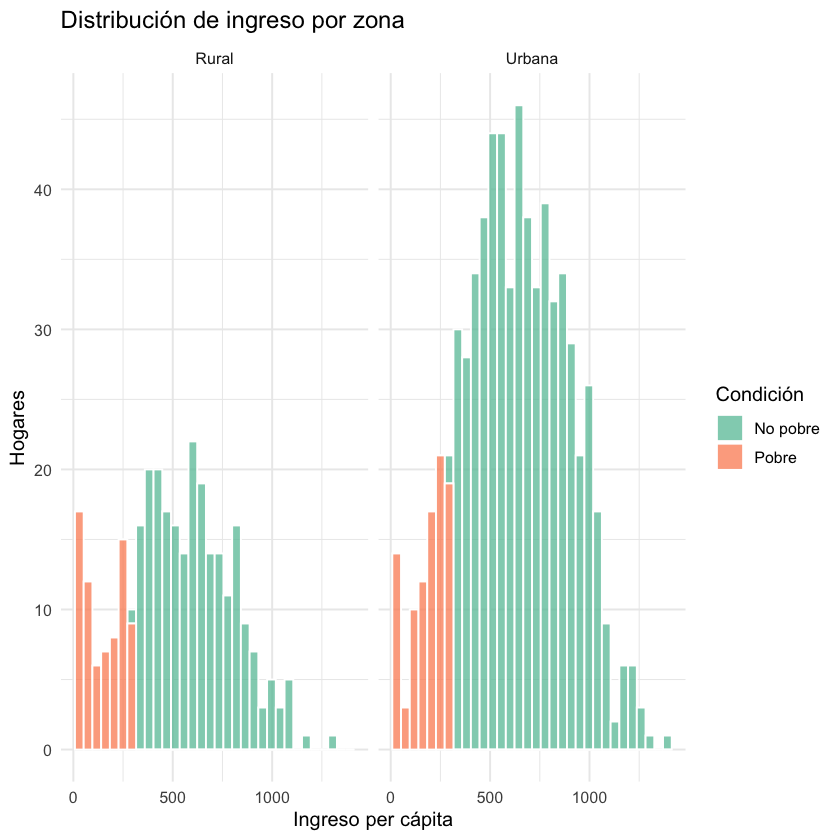

In [146]:
hogares %>%
  ggplot(aes(x = ingreso_pc, fill = pobre)) +
  geom_histogram(bins = round(nrow(hogares)^(1/2),0), alpha = .75, color = "white") +
  facet_wrap(~ area) +
  scale_fill_brewer(palette = "Set2") +
  labs(x = "Ingreso per cápita", y = "Hogares", fill = "Condición", title = "Distribución de ingreso por zona")

#### Comentarios finales

**Data leakage (fuga de información):** ocurre cuando el modelo usa, directa o indirectamente, información que no estaría disponible al momento de predecir. En este módulo puede aparecer si calculamos imputaciónes, medias, desviaciones estándar o transformaciones usando todo el dataset antes de separar entrenamiento y prueba.

En imputación, esta fuga es especialmente grave: si usamos el conjunto completo para decidir medias o modas de reemplazo, el conjunto de prueba influye en la preparación del entrenamiento. En estandarización, la fuga por usar media y desviación estándar de todo el dataset es muy pequeña, porque no usa directamente la variable objetivo.

La regla práctica es: primero separamos `train`/`test`; después aprendemos cualquier parámetro de preparación solo con `train`; finalmente aplicamos esos parámetros a `test`. Por eso, en el flujo de modelado usaremos `recipes`: `prep()` aprende la preparación en entrenamiento y `bake()` la aplica sin mirar las respuestas del conjunto de prueba.

El objetivo es que las métricas de evaluación simulen un caso real: datos nuevos, no vistos, con la misma preparación aprendida durante el entrenamiento.

## 2. Partición y remuestreo

<div style="text-align:center; margin: 0.5rem 0 1rem 0;">
  <img src="https://rsample.tidymodels.org/logo.png" alt="Logo de rsample" width="140"/>
</div>

Antes de entrenar comparamos varias formas de dividir o remuestrear los datos. La referencia es la proporción real de hogares pobres en el dataset completo. Si una partición o remuestreo queda muy lejos de esa referencia, las métricas pueden depender demasiado de cómo cayeron los casos en cada subconjunto.

Veremos: partición simple, partición estratificada, K-fold, K-fold estratificado, bootstrap y bootstrap estratificado. Para los modelos posteriores usaremos la partición estratificada train/test.

In [147]:
# Proporción real de pobreza en todos los datos.
prop_pobre_real <- mean(hogares$pobre == "Pobre")

# 1) Partición simple.
set.seed(semilla_global)
split_simple <- initial_split(hogares, prop = 0.80)
train_simple <- training(split_simple)
test_simple <- testing(split_simple)

# 2) Partición estratificada.
set.seed(semilla_global)
split_hogares <- initial_split(hogares, prop = 0.80, strata = pobre)

train <- training(split_hogares)
test <- testing(split_hogares)

# 3) K-fold sin estratos y 4) K-fold con estratos.
set.seed(semilla_global)
folds_simple <- vfold_cv(hogares, v = 5)

set.seed(semilla_global)
folds_strata <- vfold_cv(hogares, v = 5, strata = pobre)

# 5) Bootstrap sin estratos y 6) Bootstrap con estratos.
set.seed(semilla_global)
boots_simple <- bootstraps(hogares, times = 5)

set.seed(semilla_global)
boots_strata <- bootstraps(hogares, times = 5, strata = pobre)

# Resumen básico: proporción de pobreza en cada muestra.
resumen_partición <- tibble(
  particion = c(
    "Datos completos",
    "Initial split simple - Train",
    "Initial split simple - Test",
    "Initial split con strata - Train",
    "Initial split con strata - Test",
    "K-fold simple - Fold 1",
    "K-fold con strata - Fold 1",
    "Bootstrap simple - Muestra 1",
    "Bootstrap con strata - Muestra 1"
  ),
  prop_pobre = c(
    prop_pobre_real,
    mean(train_simple$pobre == "Pobre"),
    mean(test_simple$pobre == "Pobre"),
    mean(train$pobre == "Pobre"),
    mean(test$pobre == "Pobre"),
    mean(assessment(folds_simple$splits[[1]])$pobre == "Pobre"),
    mean(assessment(folds_strata$splits[[1]])$pobre == "Pobre"),
    mean(analysis(boots_simple$splits[[1]])$pobre == "Pobre"),
    mean(analysis(boots_strata$splits[[1]])$pobre == "Pobre")
  )
) %>%
  mutate(
    prop_real = prop_pobre_real,
    diferencia_vs_real = prop_pobre - prop_real
  )

write_csv(resumen_partición, file.path(output_dir, "resumen_partición.csv"))

resumen_partición

particion,prop_pobre,prop_real,diferencia_vs_real
<chr>,<dbl>,<dbl>,<dbl>
Datos completos,0.170,0.17,0.000
Initial split simple - Train,0.175,0.17,0.005
Initial split simple - Test,0.150,0.17,-0.020
Initial split con strata - Train,0.170,0.17,0.000
Initial split con strata - Test,0.170,0.17,0.000
K-fold simple - Fold 1,0.195,0.17,0.025
K-fold con strata - Fold 1,0.170,0.17,0.000
Bootstrap simple - Muestra 1,0.181,0.17,0.011
Bootstrap con strata - Muestra 1,0.170,0.17,0.000


## 3. Métricas de evaluación

<div style="text-align:center; margin: 0.5rem 0 1rem 0;">
  <img src="https://yardstick.tidymodels.org/logo.png" alt="Logo de yardstick" width="140"/>
</div>

Antes de ajustar modelos fijamos las métricas que vamos a usar. Para regresión usaremos RMSE, MAE y R cuadrado. Para clasificación usaremos accuracy, sensibilidad, especificidad, ROC AUC y una métrica probabilística: log-score, cuyo negativo es log-loss.

## 4. OLS con workflow

<div style="display:flex; justify-content:center; align-items:center; gap: 1.25rem; flex-wrap:wrap; margin: 0.5rem 0 1rem 0;">
  <img src="https://rsample.tidymodels.org/logo.png" alt="Logo de rsample" width="90"/>
  <img src="https://recipes.tidymodels.org/logo.png" alt="Logo de recipes" width="90"/>
  <img src="https://parsnip.tidymodels.org/logo.png" alt="Logo de parsnip" width="90"/>
  <img src="https://workflows.tidymodels.org/logo.png" alt="Logo de workflows" width="90"/>
  <img src="https://yardstick.tidymodels.org/logo.png" alt="Logo de yardstick" width="90"/>
</div>

OLS se usa para predecir el ingreso per cápita. En esta sección hacemos el flujo de modelado con `tidymodels`: receta de preparación, modelo, workflow, ajuste, predicción y métricas sobre `test`.

In [148]:
# La receta aprende imputación, dummies y normalización solo con train.

# Partición estratificada.
set.seed(semilla_global)
split_hogares <- initial_split(hogares, prop = 0.80, strata = pobre)

train <- training(split_hogares)
test <- testing(split_hogares)

# receta

receta_ols <- recipe(ingreso_pc ~ region + area + miembros + edad_jefe + educ_jefe + empleo_jefe +
                       vivienda_propia + internet + transferencias,
                     data = train) %>%
  step_impute_mode(all_nominal_predictors()) %>%
  step_impute_mean(all_numeric_predictors()) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_zv(all_predictors()) %>%
  step_normalize(all_numeric_predictors())

# parsnip declara OLS y workflow une preparación + modelo.
modelo_ols <- linear_reg() %>%
  set_engine("lm")

# workflow
wf_ols <- workflow() %>%
  add_recipe(receta_ols) %>%
  add_model(modelo_ols)

wf_ols

# fit() entrena el workflow completo; predict() evalúa en test.
ajuste_ols <- fit(wf_ols, data = train)

pred_ols <- predict(ajuste_ols, new_data = test) %>%
  bind_cols(test %>% select(ingreso_pc))

head(pred_ols)

# yardstick
metr <- metric_set(rmse, rsq, mae)

metricas_ols <- metr(
  pred_ols,
  truth = ingreso_pc,
  estimate = .pred
)

# Guardar output
write_csv(metricas_ols, file.path(output_dir, "metricas_ols.csv"))


══ Workflow ════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: linear_reg()

── Preprocessor ────────────────────────────────────────────────────────────────
5 Recipe Steps

• step_impute_mode()
• step_impute_mean()
• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────
Linear Regression Model Specification (regression)

Computational engine: lm 


.pred,ingreso_pc
<dbl>,<dbl>
883.8130,978.87
512.4636,450.81
681.9965,748.72
815.1969,898.21
472.5817,452.77
366.2893,472.25


## 5. Regresión logística y métricas con workflow

<div style="display:flex; justify-content:center; align-items:center; gap: 1.25rem; flex-wrap:wrap; margin: 0.5rem 0 1rem 0;">
  <img src="https://rsample.tidymodels.org/logo.png" alt="Logo de rsample" width="90"/>
  <img src="https://recipes.tidymodels.org/logo.png" alt="Logo de recipes" width="90"/>
  <img src="https://parsnip.tidymodels.org/logo.png" alt="Logo de parsnip" width="90"/>
  <img src="https://workflows.tidymodels.org/logo.png" alt="Logo de workflows" width="90"/>
  <img src="https://yardstick.tidymodels.org/logo.png" alt="Logo de yardstick" width="90"/>
</div>

La regresión logística se usa para clasificar hogares pobres y no pobres. El workflow es el mismo: receta, modelo, ajuste, predicción y evaluación con `yardstick`. Aquí miramos tanto clases predichas como probabilidades.

In [149]:
# Partición estratificada.
set.seed(semilla_global)
split_hogares <- initial_split(hogares, prop = 0.80, strata = pobre)

train <- training(split_hogares)
test <- testing(split_hogares)


# Receta de clasificación: misma preparación, distinto objetivo.
receta_logit <- recipe(pobre ~ region + area + miembros + edad_jefe + educ_jefe + empleo_jefe +
                         vivienda_propia + internet + transferencias,
                       data = train) %>%
  step_impute_mode(all_nominal_predictors()) %>%
  step_impute_mean(all_numeric_predictors()) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_zv(all_predictors()) %>%
  step_normalize(all_numeric_predictors())

modelo_logit <- logistic_reg() %>%
  set_engine("glm")

wf_logit <- workflow() %>%
  add_recipe(receta_logit) %>%
  add_model(modelo_logit)

wf_logit

ajuste_logit <- fit(wf_logit, data = train)

pred_logit <- predict(ajuste_logit, new_data = test, type = "prob") %>%
  bind_cols(predict(ajuste_logit, new_data = test, type = "class")) %>%
  bind_cols(test %>% select(pobre))

head(pred_logit)

# metric_set
metr <- metric_set(
  accuracy,
  precision,
  recall,
  f_meas,
  roc_auc
)

metricas_logit <- metr(
  pred_logit,
  truth = pobre,
  estimate = .pred_class,
  .pred_Pobre,
  event_level = "second"
)

matriz_confusion <- conf_mat(
  pred_logit,
  truth = pobre,
  estimate = .pred_class
)

write_csv(metricas_logit, file.path(output_dir, "metricas_logit.csv"))

metricas_logit
matriz_confusion


══ Workflow ════════════════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: logistic_reg()

── Preprocessor ────────────────────────────────────────────────────────────────
5 Recipe Steps

• step_impute_mode()
• step_impute_mean()
• step_dummy()
• step_zv()
• step_normalize()

── Model ───────────────────────────────────────────────────────────────────────
Logistic Regression Model Specification (classification)

Computational engine: glm 


.pred_No pobre,.pred_Pobre,.pred_class,pobre
<dbl>,<dbl>,<fct>,<fct>
0.9999123,8.766246e-05,No pobre,No pobre
0.9575379,4.246215e-02,No pobre,No pobre
0.9966699,3.330119e-03,No pobre,No pobre
1.0000000,1.573339e-10,No pobre,No pobre
0.9048046,9.519541e-02,No pobre,No pobre
0.6686584,3.313416e-01,No pobre,No pobre


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.9100000
precision,binary,0.7352941
recall,binary,0.7352941
f_meas,binary,0.7352941
roc_auc,binary,0.9466690


          Truth
Prediction No pobre Pobre
  No pobre      157     9
  Pobre           9    25

## 6. Trabajo en clase

<div style="display:flex; justify-content:center; align-items:center; gap: 1.25rem; flex-wrap:wrap; margin: 0.5rem 0 1rem 0;">
  <img src="https://rsample.tidymodels.org/logo.png" alt="Logo de rsample" width="90"/>
  <img src="https://recipes.tidymodels.org/logo.png" alt="Logo de recipes" width="90"/>
  <img src="https://parsnip.tidymodels.org/logo.png" alt="Logo de parsnip" width="90"/>
  <img src="https://workflows.tidymodels.org/logo.png" alt="Logo de workflows" width="90"/>
  <img src="https://yardstick.tidymodels.org/logo.png" alt="Logo de yardstick" width="90"/>
</div>

Ahora repetimos el mismo workflow con `data_pobreza_INEC.xlsx`. La variable `NBIMEF` se usa como objetivo continuo para OLS. Para la regresión logística creamos una variable binaria sencilla: cantones con `NBIMEF` menos del primer cuartil. Quitamos otras medidas directas de NBI para evitar una fuga de información demasiado obvia.

In [150]:
# Cargar datos reales del INEC.
data_inec <- suppressMessages(read_excel("data/data_pobreza_INEC.xlsx"))

In [151]:
# 1. Desde una celda R con system()
system("conda run -n rbase jupyter nbconvert --to html modulo1.ipynb")